In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px
import os


In [ ]:
#loading the dataset
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Yinka/Project/2021 - Uni of Hull - Autumn Open Days _ January deadline_tacticsPerformance.csv")
data.head()

,campaign_id,project_id,kpi_conversion_id,platform,tactic_name,ad_type,status,status_enum,funnel,budget,...,clicks,ctr,cpl,cpc,cpm,pricingType,tags,note,alwaysOnActivity,scheduleType
0,61168b35c9d0d14a86e0b020,22965,NaN,UCAS,Open Days - UCAS - November Email Boost,2021 Email,Ended,4,Connection,6000.00,...,175.0,1.77,0.00,38.10,675.31,standard,[],NaN,False,standard
1,61168b35c9d0d14a86e0b020,23902,NaN,Facebook Family,A/B test messaging - UCAS deadline remarketing,Mix Media Link Post,Ended,4,Action,507.33,...,500.0,2.08,0.00,1.01,21.10,standard,[],NaN,False,standard
2,61168b35c9d0d14a86e0b020,18289,NaN,Snapchat,Open Days - Snapchat - Traditional Students - ...,Snap Ads,Ended,4,Action,4291.24,...,13031.0,0.77,286.08,0.33,2.54,standard,[],NaN,False,flighting
3,61168b35c9d0d14a86e0b020,17844,NaN,Snapchat,Brand - Snapchat - Story Ads - Bronze Locations,Story Ads,Ended,4,Connection,3471.02,...,236.0,0.03,0.00,14.71,3.84,standard,[],NaN,False,standard
4,61168b35c9d0d14a86e0b020,18288,NaN,Facebook Family,Open Days - Facebook - Mature Students - Gold ...,Mix Media Link Post,Ended,4,Action,4357.25,...,1958.0,0.54,622.46,2.23,12.00,standard,[],NaN,False,flighting


In [ ]:
#accessing the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        48 non-null     object 
 1   project_id         48 non-null     int64  
 2   kpi_conversion_id  3 non-null      object 
 3   platform           48 non-null     object 
 4   tactic_name        48 non-null     object 
 5   ad_type            48 non-null     object 
 6   status             48 non-null     object 
 7   status_enum        48 non-null     int64  
 8   funnel             48 non-null     object 
 9   budget             48 non-null     float64
 10  spent              48 non-null     float64
 11  currency           48 non-null     object 
 12  remaining_spend    48 non-null     float64
 13  start_date         48 non-null     object 
 14  end_date           48 non-null     object 
 15  percent_spent      48 non-null     float64
 16  percent_duration   48 non-nu

In [ ]:
#chekcking data summary
data.describe()

,project_id,status_enum,budget,spent,remaining_spend,percent_spent,percent_duration,kpi_percentage,kpi_performance,kpi_value,kpi_to_date,impressions,clicks,ctr,cpl,cpc,cpm
count,48.000000,48.0,48.000000,48.000000,48.000000,48.000000,48.0,45.000000,48.000000,4.800000e+01,4.700000e+01,4.600000e+01,46.00000,43.000000,48.000000,45.000000,44.000000
mean,18403.520833,4.0,5142.862083,5142.852292,0.009792,97.916458,100.0,126.088667,118.208125,2.667055e+05,3.541674e+05,6.738055e+05,5004.76087,2.166977,54.253333,207.257333,122.926364
std,1091.558908,0.0,3000.857276,3000.866267,0.048837,14.433726,0.0,88.582039,91.089427,4.704574e+05,7.975978e+05,8.256556e+05,8588.35248,6.150743,178.423476,1313.819919,453.866615
min,17722.000000,4.0,0.010000,0.000000,-0.010000,0.000000,100.0,9.430000,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,1.080000
25%,17917.750000,4.0,3509.442500,3509.442500,0.000000,100.000000,100.0,86.510000,75.155000,1.385000e+02,2.920650e+02,1.559532e+05,307.50000,0.095000,0.000000,0.660000,4.985000
50%,18296.500000,4.0,4357.250000,4357.250000,0.000000,100.000000,100.0,106.170000,104.440000,8.238000e+03,1.076200e+04,4.552785e+05,1796.00000,0.330000,0.000000,2.320000,10.320000
75%,18310.250000,4.0,6151.727500,6151.727500,0.000000,100.000000,100.0,131.140000,128.890000,4.041668e+05,4.500580e+05,8.202400e+05,6531.25000,1.165000,0.000000,7.610000,20.650000
max,23902.000000,4.0,12000.000000,12000.000000,0.290000,100.000000,100.0,418.050000,418.050000,2.228620e+06,4.832551e+06,4.832551e+06,49703.00000,33.260000,871.450000,8823.530000,2902.480000


In [ ]:
#checking for missing values
data.isnull().sum()

campaign_id           0
project_id            0
kpi_conversion_id    45
platform              0
tactic_name           0
ad_type               0
status                0
status_enum           0
funnel                0
budget                0
spent                 0
currency              0
remaining_spend       0
start_date            0
end_date              0
percent_spent         0
percent_duration      0
kpi_percentage        3
kpi_performance       0
primary_kpi           0
kpi_value             0
kpi_to_date           1
impressions           2
clicks                2
ctr                   5
cpl                   0
cpc                   3
cpm                   4
pricingType           0
tags                  0
note                 46
alwaysOnActivity      0
scheduleType          0
dtype: int64

## Filling of missing values

In [ ]:
# looping through each of the columns
for col in data.columns:
     data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
#checking for missing values
data.isnull().sum()

StudentCode           0
MCRCourseCode         0
UCASCourseCode        0
AcademicYear          0
ProgrammeOfStudy      0
Route                 0
FeeStatusCode         0
FeeStatus             0
DateCreated           0
CycleOfApplication    0
dtype: int64

### Acessing the Uniqueness of each column

In [ ]:
# setting default plot size
plt.rcParams['figure.figsize'] = [12, 8]

In [ ]:
data['StudentCode'].unique()

array([200303538, 200304410, 200509243, ..., 202105492, 202108422,
       202108444])

In [ ]:
data['MCRCourseCode'].value_counts()

UGMBBSXFU01    3646
UGNURAXFU01    2451
UGPARAXFU01    1848
UGLAWXXFU01    1285
UGPSYCXFU01    1246
               ... 
UGFRSTAFU01       1
UGCBTLAFU01       1
UGENPHXFU01       1
UGMLBMAFU01       1
UGBIMEAFU01       1
Name: MCRCourseCode, Length: 285, dtype: int64

<AxesSubplot:xlabel='MCRCourseCode'>

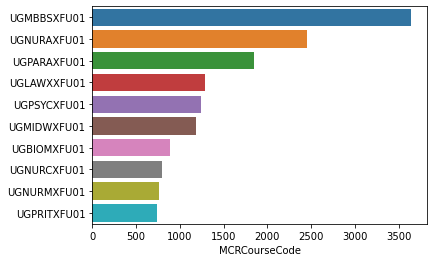

In [ ]:
# ploting the top 10 and bottom 10 MCR Course Code
sns.barplot(y= data['MCRCourseCode'].value_counts()[:10].index, x=data['MCRCourseCode'].value_counts()[:10])

In [ ]:
data['MCRCourseCode'].value_counts()[-10:]

UGESSSXFU01    1
UGBECOXFU01    1
UGSCGYFFU01    1
UGSECCXFU01    1
UGBIOCFFU01    1
UGFRSTAFU01    1
UGCBTLAFU01    1
UGENPHXFU01    1
UGMLBMAFU01    1
UGBIMEAFU01    1
Name: MCRCourseCode, dtype: int64

<AxesSubplot:xlabel='MCRCourseCode'>

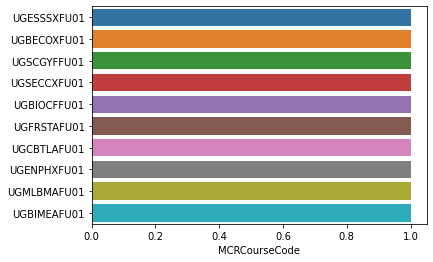

In [ ]:
# ploting the top 10 and bottom 10 MCR Course Code
sns.barplot(y= data['MCRCourseCode'].value_counts()[-10:].index, x=data['MCRCourseCode'].value_counts()[-10:])

In [ ]:
data['UCASCourseCode'].value_counts()

A100    3647
B740    2632
B780    1848
M100    1285
C800    1246
        ... 
H162       1
L400       1
R9N1       1
C708       1
R110       1
Name: UCASCourseCode, Length: 280, dtype: int64

In [ ]:
data['AcademicYear'].value_counts()

2021/22    15041
2022/23    14254
2020/21    12741
Name: AcademicYear, dtype: int64

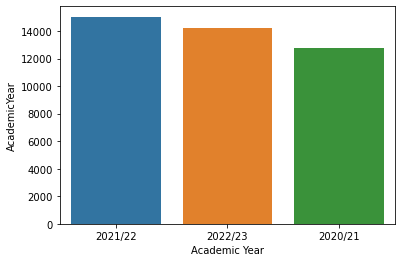

In [ ]:
#creating plot for the academic year
sns.barplot(y=data['AcademicYear'].value_counts(), x= data['AcademicYear'].value_counts().index)
plt.xlabel('Academic Year')
plt.show()

In [ ]:
data['ProgrammeOfStudy'].value_counts()

BSc         20145
BA          12326
MB BS        4318
LLB          2178
BEng         1631
MA            538
MEng          519
MPhys         106
FdEd           79
MChem          70
MSci           38
MSc            35
BEd            32
MBiochem       16
BMus            4
Name: ProgrammeOfStudy, dtype: int64

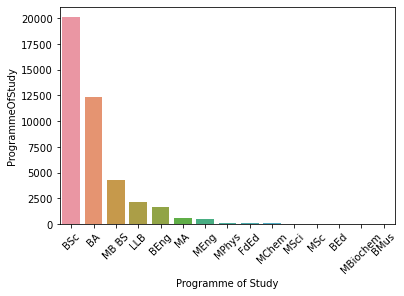

In [ ]:
#creating plot for the academic year
sns.barplot(y=data['ProgrammeOfStudy'].value_counts(), x= data['ProgrammeOfStudy'].value_counts().index)
plt.xticks(ticks=range(len(data['ProgrammeOfStudy'].value_counts().index)), rotation=45)
plt.xlabel('Programme of Study')
plt.show()

In [ ]:
data['FeeStatus'].value_counts()

Home                               34926
Overseas                            3944
Query                               3129
Channel Islands and Isle of Man       35
Name: FeeStatus, dtype: int64

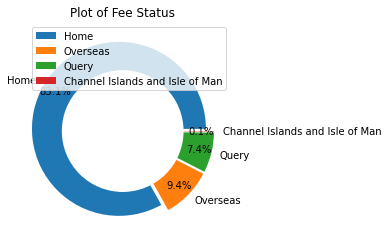

In [ ]:

# colors
colors = ['#FF0000', '#0000FF', '#FFFF00', '#ADFF2F']

# explosion
explode = (0.05, 0.05, 0.05, 0.05)

# Pie Chart
plt.pie(data['FeeStatus'].value_counts(), labels= data['FeeStatus'].value_counts().index,
		autopct='%1.1f%%', pctdistance=0.85,
		explode=explode)

# draw circle
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()

# Adding Circle in Pie chart
fig.gca().add_artist(centre_circle)

# Add Legends
plt.legend(data['FeeStatus'].value_counts().index, loc="upper right")

# Adding Title of chart
plt.title('Plot of Fee Status')

# Displaying Chart
plt.show()


In [ ]:
# don't really understand the meaning of date created
data['DateCreated'].value_counts()

27/01/2022    2155
15/03/2021    1960
21/10/2021    1796
16/01/2020    1043
26/01/2022     872
              ... 
22/03/2019       1
01/02/2019       1
28/01/2019       1
02/10/2019       1
18/06/2019       1
Name: DateCreated, Length: 969, dtype: int64

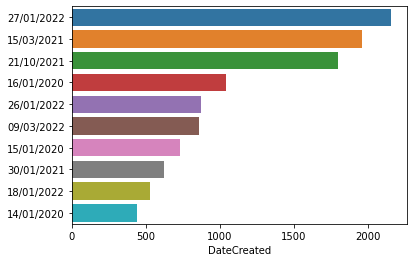

In [ ]:
# ploting the top 10 DateCreated
sns.barplot(y= data['DateCreated'].value_counts()[:10].index, x=data['DateCreated'].value_counts()[:10])
plt.show()

In [ ]:
data['CycleOfApplication'].value_counts()

2021    15150
2022    13731
2020    12635
2019      518
2018        2
Name: CycleOfApplication, dtype: int64

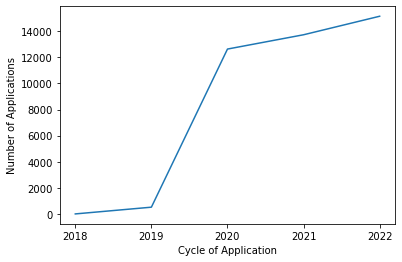

In [ ]:
#creating a line plot
sns.lineplot(y=sorted(data['CycleOfApplication'].value_counts().values), x= sorted(data['CycleOfApplication'].value_counts().index.astype(str)))
plt.xlabel('Cycle of Application')
plt.ylabel('Number of Applications')
plt.show()

In [ ]:
data.head()

,StudentCode,MCRCourseCode,UCASCourseCode,AcademicYear,ProgrammeOfStudy,Route,FeeStatusCode,FeeStatus,DateCreated,CycleOfApplication
0,200303538,UGNURAXFU01,B740,2022/23,BSc,Nursing (Adult),H,Home,27/01/2022,2022
1,200304410,UGNURLXFU01,B761,2022/23,BSc,Nursing (Learning Disability),H,Home,01/07/2021,2021
2,200509243,UGNURAXFU01,B740,2022/23,BSc,Nursing (Adult),H,Home,17/12/2020,2021
3,200604317,PMSOCWXFU01,L508,2022/23,MA,Social Work,H,Home,11/12/2021,2022
4,200614635,UGODPRXFU01,B990,2022/23,BSc,Operating Department Practice,H,Home,04/01/2021,2021
